# Correlation Analysis and Comparison to Null Models

Here, we demonstrate how the centrality measurements correlate with one another and relative the number of proteins in the proteome. Then, we compare the correlation results to randomized null models that either perform degree-preservation or generate artificial protein domain architectures based on the domain frequencies.

In [ ]:
import os
import dansy
import networkx as nx
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import Counter
from dansy import nullModels

In [2]:
ref = dansy.import_proteome_files(ref_file_dir='./data/Current_Human_Proteome',
                                  ref_file_suffix='2026_0715.csv')

proteome_dansy = dansy.dansy(ref = ref, n=10)

Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


In [3]:
orig_bc = nx.betweenness_centrality(proteome_dansy.G, normalized=False)
orig_dc = dict(nx.degree(proteome_dansy.G))

Now let's show how the centrality measurements correspond to protein counts

In [36]:
prot_counts = {i:len(proteome_dansy.interpro2uniprot[i]) for i in orig_bc.keys()}

In [37]:
# Let's grab the correlation values of the centrality and protein counts
bc_cor = stats.spearmanr(list(orig_bc.values()), list(prot_counts.values()))
bc_cor

SignificanceResult(statistic=0.18128864415938187, pvalue=1.1432819596084412e-58)

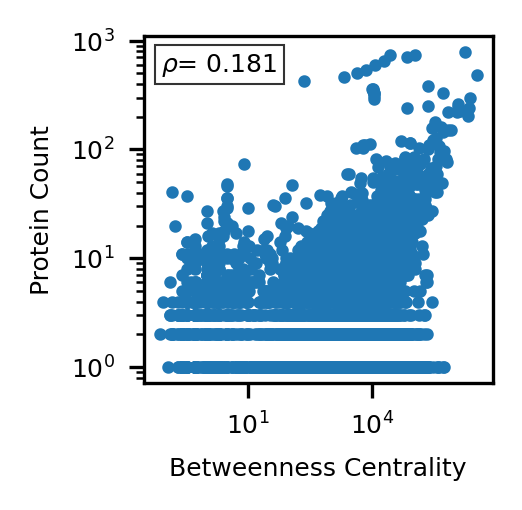

In [38]:
plt.figure(figsize=(1.5,1.5), dpi = 300)
plt.loglog(orig_bc.values(), prot_counts.values(),'o', markersize = 2)
plt.tick_params(axis = 'both', labelsize = 6)
plt.ylabel('Protein Count', fontdict=dict(fontsize = 6))
plt.xlabel('Betweenness Centrality', fontdict=dict(fontsize = 6))
plt.annotate(r'$\rho$'+ f'= {bc_cor.statistic:.3f}',
             xy = (0.05,0.9),xycoords='axes fraction',
             fontsize=6,
             bbox=dict(facecolor='white', edgecolor='k',lw=0.5, ls = '-', pad = 1.5, alpha=0.8))

plt.savefig('Figures/Manuscript/Supplemental_Figure_2/Betweenness_Protein_correlation.svg')

In [39]:
# Let's grab the correlation values of the centrality and protein counts
dc_cor = stats.spearmanr(list(orig_dc.values()), list(prot_counts.values()))
dc_cor

SignificanceResult(statistic=0.2883409814637776, pvalue=2.4088913931731308e-149)

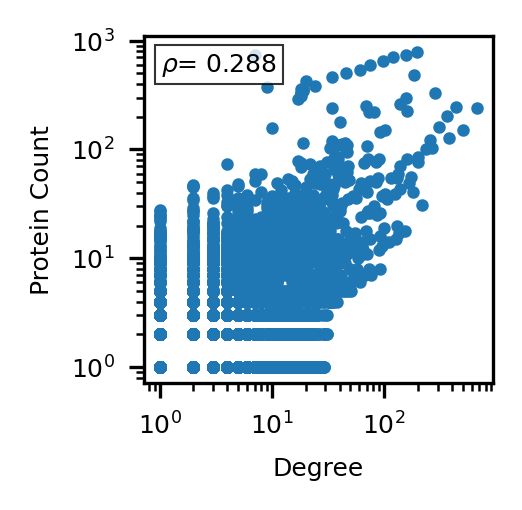

In [40]:
plt.figure(figsize=(1.5,1.5), dpi = 300)
plt.loglog(orig_dc.values(), prot_counts.values(),'o', markersize = 2)
plt.tick_params(axis = 'both', labelsize = 6)
plt.ylabel('Protein Count', fontdict=dict(fontsize = 6))
plt.xlabel('Degree', fontdict=dict(fontsize = 6))


plt.annotate(r'$\rho$'+ f'= {dc_cor.statistic:.3f}',
             xy = (0.05,0.9),xycoords='axes fraction',
             fontsize=6,
             bbox=dict(facecolor='white', edgecolor='k',lw=0.5, ls = '-', pad = 1.5, alpha=0.8))
plt.savefig('Figures/Manuscript/Supplemental_Figure_2/Protein_Degree_correlation.svg')

In [5]:
# Now creating a degree preserving randomization of the whole proteome
dpr_model = nullModels.generate_degree_preservation_model(proteome_dansy.G, seed=123)
dpr_bc = nx.betweenness_centrality(dpr_model, normalized=False)
dpr_dc = dict(nx.degree(dpr_model))

In [11]:
# Now the domain-frequency version
dfr_model = nullModels.generate_domain_freq_null_model(proteome_dansy,cap = 40, seed = 123)


Generating random protein domain architectures
Now generating the DANSy network for the null model
Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


In [12]:
dfr_bc = nx.betweenness_centrality(dfr_model.G,normalized = False)
dfc_dc = dict(nx.degree(dfr_model.G))

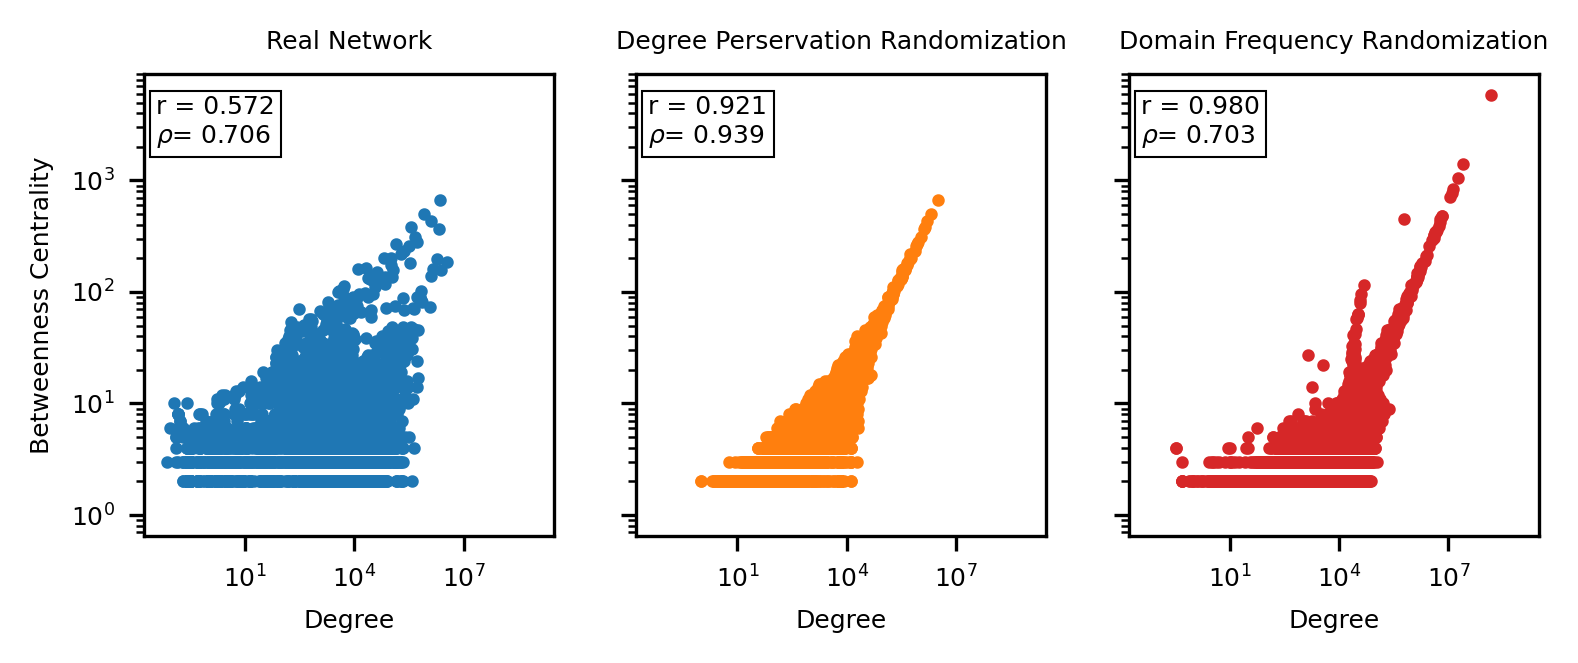

In [35]:
f, axs = plt.subplots(1,3, sharex=True, sharey=True, figsize = (6,2), dpi = 300)
dpr_cent_cor = stats.spearmanr(list(dpr_bc.values()), list(dpr_dc.values()))
dpr_pear=stats.pearsonr(list(dpr_bc.values()), list(dpr_dc.values()))
axs[1].loglog(dpr_bc.values(), dpr_dc.values(),'o', color = 'tab:orange', markersize = 2)
# plt.tick_params(axis = 'both', labelsize = 6)
# plt.ylabel('Degree Centrality', fontdict=dict(fontsize = 6))
# plt.xlabel('Betweenness Centrality', fontdict=dict(fontsize = 6))
axs[1].annotate(f"r = {dpr_pear.statistic:.3f}\n"+r'$\rho$'+ f'= {dpr_cent_cor.statistic:.3f}',
             xy = (0.03,0.85),xycoords='axes fraction',
             fontsize=6,
             bbox=dict(facecolor='white', edgecolor='k',lw=0.5, ls = '-', pad = 1.5))
axs[1].set_title('Degree Perservation Randomization',fontdict={'fontsize':6})
# plt.savefig('Figures/Manuscript/Supplemental_Figure_2/Random_Network_centrality_correlation.svg')
# Get the centrality correlation results
real_cent_cor = stats.spearmanr(list(orig_bc.values()), list(orig_dc.values()))
real_pear = stats.pearsonr(list(orig_bc.values()), list(orig_dc.values()))

axs[0].loglog(orig_bc.values(), orig_dc.values(),'o',markersize = 2)
axs[0].annotate(f"r = {real_pear.statistic:.3f}\n"+r'$\rho$'+ f'= {real_cent_cor.statistic:.3f}',
             xy = (0.03,0.85),xycoords='axes fraction',
             fontsize=6,
             bbox=dict(facecolor='white', edgecolor='k',lw=0.5, ls = '-', pad = 1.5))
axs[0].set_title('Real Network', fontdict={'fontsize':6})
# plt.savefig('Figures/Manuscript/Supplemental_Figure_2/Real_Network_centrality_correlation.svg')

dfr_cent_cor = stats.spearmanr(list(dfr_bc.values()), list(dfc_dc.values()))
dfr_pear=stats.pearsonr(list(dfr_bc.values()), list(dfc_dc.values()))
axs[2].loglog(dfr_bc.values(), dfc_dc.values(),'o', color = 'tab:red', markersize = 2)
axs[2].set_title('Domain Frequency Randomization',fontdict={'fontsize':6})
axs[2].annotate(f"r = {dfr_pear.statistic:.3f}\n"+r'$\rho$'+ f'= {dfr_cent_cor.statistic:.3f}',
             xy = (0.03,0.85),xycoords='axes fraction',
             fontsize=6,
             bbox=dict(facecolor='white', edgecolor='k',lw=0.5, ls = '-', pad = 1.5))

axs[0].set_ylabel('Betweenness Centrality', fontdict=dict(size=6))
for ax in axs:
    ax.set_xlabel('Degree', fontdict=dict(size=6))
    ax.margins(x = 0.15)
    ax.tick_params(labelsize = 6)
f.savefig('Figures/Manuscript/Supplemental_Figure_2/Null_model_comparison.svg')